In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/brain-tumor-classification/dataset/archive.zip" -d "/content/drive/MyDrive/brain-tumor-classification/dataset/"

Archive:  /content/drive/MyDrive/brain-tumor-classification/dataset/archive.zip


In [2]:
!cp -r "/content/drive/MyDrive/brain-tumor-classification/dataset" /content/

In [3]:
# Define paths to training and testing datasets

train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

In [4]:
# Imports
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import classification_report, confusion_matrix

In [5]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print("Mixed Precision:", mixed_precision.global_policy())

Mixed Precision: <DTypePolicy "mixed_float16">


In [6]:
# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
# Load datasets


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

Found 5723 files belonging to 4 classes.
Using 4579 files for training.
Found 5723 files belonging to 4 classes.
Using 1144 files for validation.
Found 1430 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
# Optimize dataset performance

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Data Augmentation INSIDE model (runs on GPU)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze first 70%
total_layers = len(base_model.layers)
freeze_until = int(0.7 * total_layers)

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

for layer in base_model.layers[freeze_until:]:
    layer.trainable = True

# FULL MODEL PIPELINE
inputs = layers.Input(shape=(224, 224, 3))

# Apply augmentation only during training
x = data_augmentation(inputs)

# Preprocessing (VERY IMPORTANT for EfficientNet)
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Base model
x = base_model(x, training=False)

# Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 3,086,816 (11.78 MB)

 Non-trainable params: 972,999 (3.71 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "/content/drive/MyDrive/brain-tumor-classification/models/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
# Train the model

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 126s 414ms/step - accuracy: 0.7382 - loss: 0.7360 - val_accuracy: 0.8505 - val_loss: 0.4337 - learning_rate: 1.0000e-04
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - accuracy: 0.8805 - loss: 0.3333 - val_accuracy: 0.9135 - val_loss: 0.2306 - learning_rate: 1.0000e-04
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.9098 - loss: 0.2544 - val_accuracy: 0.9301 - val_loss: 0.1852 - learning_rate: 1.0000e-04
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - accuracy: 0.9306 - loss: 0.1883 - val_accuracy: 0.9414 - val_loss: 0.1592 - learning_rate: 1.0000e-04
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.9437 - loss: 0.1479 - val_accuracy: 0.9423 - val_loss: 0.1489 - learning_rate: 1.0000e-04
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.9526 - loss: 0.1223 - val_accuracy: 0.9519 - val_loss: 0.1260 - learning_rate: 1.0000e-04
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 1

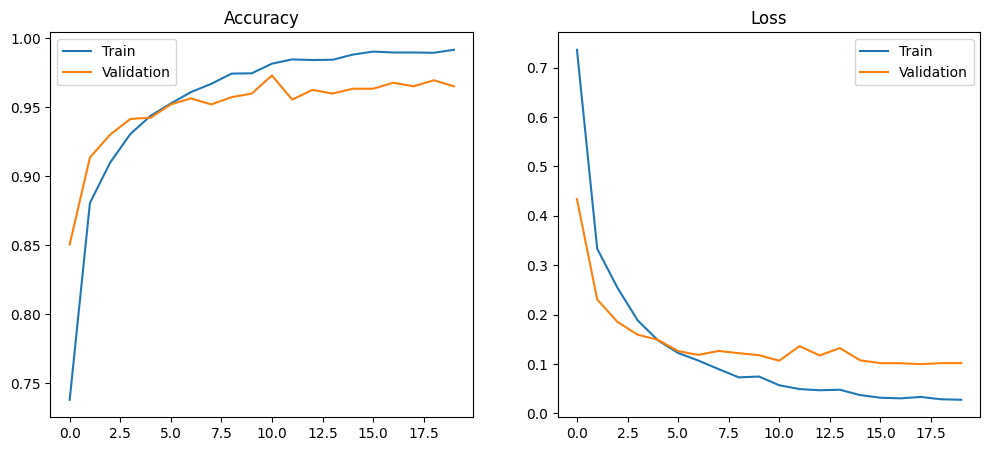

In [ ]:
# Plot training history

def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Accuracy')
    plt.legend(['Train', 'Validation'])

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Loss')
    plt.legend(['Train', 'Validation'])

    plt.show()

plot_history(history)

In [11]:
# Load the best model and evaluate on test set

def evaluate_model(model, dataset, class_names):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


Classification Report:

              precision    recall  f1-score   support

      glioma       0.97      0.97      0.97       324
  meningioma       0.96      0.94      0.95       355
     notumor       0.99      0.98      0.99       400
   pituitary       0.97      0.99      0.98       351

    accuracy                           0.97      1430
   macro avg       0.97      0.97      0.97      1430
weighted avg       0.97      0.97      0.97      1430



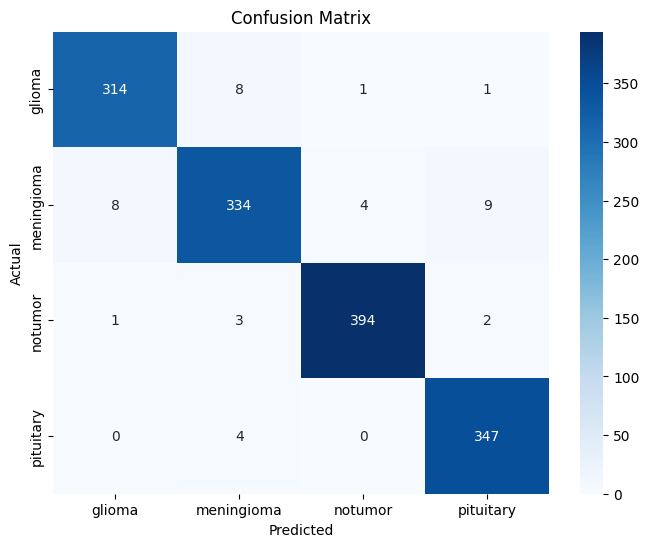

In [12]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/brain-tumor-classification/models/best_model.keras"
)

evaluate_model(model, test_ds, class_names)